In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
!git clone https://github.com/falkodz/TER.git /content/TER

Cloning into '/content/TER'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 26 (delta 7), reused 21 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 1.38 MiB | 18.60 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [4]:
!ls /content/TER

figures  notebooks  README.md  requirements.txt  src


In [6]:
import os, shutil

# Créer le dossier data
os.makedirs('/content/TER/data', exist_ok=True)

# Copier le CSV
shutil.copy('/content/drive/MyDrive/Colab Notebooks/ChatGPT_final.csv',
            '/content/TER/data/ChatGPT_final.csv')
print("Done ✓")

Done ✓


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/TER/data/ChatGPT_final.csv',
                 usecols=['cleaned_tweet', 'sentiment', 'Date'],
                 low_memory=False)

df = df.dropna(subset=['cleaned_tweet', 'sentiment'])
df = df[df['cleaned_tweet'].str.strip() != '']

print(f"Shape: {df.shape}")
print(df['sentiment'].value_counts())

Shape: (476193, 3)
sentiment
positive    249982
neutral     150924
negative     75287
Name: count, dtype: int64


In [8]:
import time

print("Building TF-IDF matrix...")
t0 = time.time()
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=3)
X = tfidf.fit_transform(df['cleaned_tweet'])
y = df['sentiment']
print(f"Done ✓ ({time.time()-t0:.1f}s) — Matrix shape: {X.shape}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Building TF-IDF matrix...
Done ✓ (52.9s) — Matrix shape: (476193, 50000)
Train: 333335 | Val: 71429 | Test: 71429


In [9]:
print("Training Logistic Regression...")
t0 = time.time()
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
print(f"Done ✓ ({time.time()-t0:.1f}s)")

y_pred_lr = lr.predict(X_val)
f1_lr = f1_score(y_val, y_pred_lr, average='macro')
print(f"\nLogistic Regression — F1 macro: {f1_lr:.4f}")
print(classification_report(y_val, y_pred_lr))

Training Logistic Regression...
Done ✓ (88.4s)

Logistic Regression — F1 macro: 0.8327
              precision    recall  f1-score   support

    negative       0.70      0.80      0.75     11293
     neutral       0.83      0.90      0.87     22638
    positive       0.93      0.84      0.89     37498

    accuracy                           0.86     71429
   macro avg       0.82      0.85      0.83     71429
weighted avg       0.86      0.86      0.86     71429



In [10]:
print("Training SVM...")
t0 = time.time()
svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm.fit(X_train, y_train)
print(f"Done ✓ ({time.time()-t0:.1f}s)")

y_pred_svm = svm.predict(X_val)
f1_svm = f1_score(y_val, y_pred_svm, average='macro')
print(f"\nSVM — F1 macro: {f1_svm:.4f}")
print(classification_report(y_val, y_pred_svm))

Training SVM...
Done ✓ (90.5s)

SVM — F1 macro: 0.8371
              precision    recall  f1-score   support

    negative       0.74      0.75      0.75     11293
     neutral       0.85      0.89      0.87     22638
    positive       0.91      0.88      0.90     37498

    accuracy                           0.86     71429
   macro avg       0.83      0.84      0.84     71429
weighted avg       0.87      0.86      0.86     71429



              Model  F1 Macro
Logistic Regression    0.8327
          LinearSVC    0.8371
              Model  F1 Macro
Logistic Regression    0.8327
          LinearSVC    0.8371


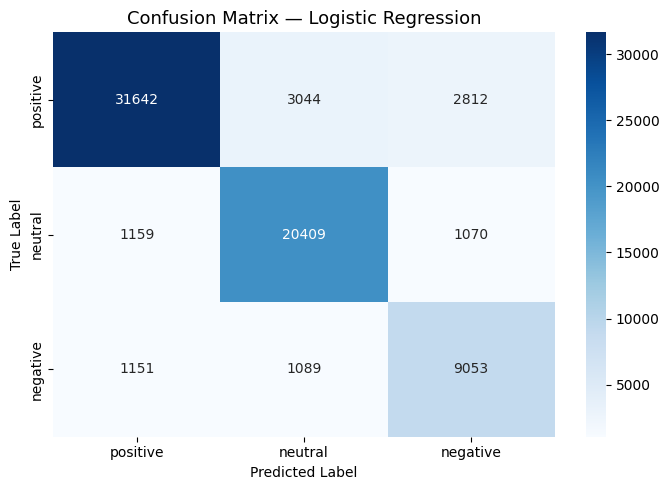

Models saved ✓
Best model: SVM


In [13]:
# Tableau comparatif
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'LinearSVC'],
    'F1 Macro': [round(f1_lr, 4), round(f1_svm, 4)]
})
print(results.to_string(index=False))

import os

# Tableau comparatif
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'LinearSVC'],
    'F1 Macro': [round(f1_lr, 4), round(f1_svm, 4)]
})
print(results.to_string(index=False))

# Matrice de confusion LR
cm = confusion_matrix(y_val, y_pred_lr, labels=['positive', 'neutral', 'negative'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive', 'neutral', 'negative'],
            yticklabels=['positive', 'neutral', 'negative'])
plt.title('Confusion Matrix — Logistic Regression', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/TER/figures/05_confusion_matrix.png', dpi=150)
plt.show()

# Créer outputs et sauvegarder
os.makedirs('/content/TER/outputs', exist_ok=True)
best_model = lr if f1_lr >= f1_svm else svm
joblib.dump(best_model, '/content/TER/outputs/baseline_model.pkl')
joblib.dump(tfidf, '/content/TER/outputs/tfidf_vectorizer.pkl')
print("Models saved ✓")
print(f"Best model: {'Logistic Regression' if f1_lr >= f1_svm else 'SVM'}")

In [14]:
import subprocess

# Config git
subprocess.run(['git', 'config', 'user.email', 'ton@email.com'], cwd='/content/TER')
subprocess.run(['git', 'config', 'user.name', 'falkodz'], cwd='/content/TER')

# Add + commit + push
subprocess.run(['git', 'add', '.'], cwd='/content/TER')
subprocess.run(['git', 'commit', '-m', 'Add baseline model: TF-IDF + LR + SVM (F1=0.837)'], cwd='/content/TER')
result = subprocess.run(
    ['git', 'push', f'https://TON_TOKEN@github.com/falkodz/TER.git', 'main'],
    cwd='/content/TER', capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)


To https://github.com/falkodz/TER.git
   8c0994c..1475fdb  main -> main

